<a href="https://colab.research.google.com/github/linda-bsharat/telco-customer-churn-prediction/blob/main/notebooks/%2003_model_building.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#03 - Model Building & Evaluation

In this stage of the project, we build and evaluate a machine learning model to predict customer churn.  
The goal is to train a model that can identify customers who are likely to leave the company.

The main steps in this stage include:

1. Preparing the dataset for machine learning.
2. Splitting the data into training and testing sets.
3. Training a machine learning model.
4. Making predictions on the test data.
5. Evaluating the model's performance using different metrics.


###**1. Import Libraries**

In [1]:
# Import required libraries for machine learning

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report,
    precision_score, recall_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

sns.set_theme(style='whitegrid')
print(f'TensorFlow version: {tf.__version__}')


TensorFlow version: 2.19.0


### **2. Load Clean Dataset**

In [2]:
# Load the cleaned dataset

df = pd.read_csv("https://raw.githubusercontent.com/linda-bsharat/telco-customer-churn-prediction/refs/heads/main/data/telco_customer_data_cleaned.csv")

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,PaperlessBilling,Churn,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,IsNewCustomer,IsLongTermCustomer,AvgMonthlyCharge,TotalServices
0,1,0,0,1,3.0,1,2,0,0,0,...,0,1,0,0,0,1,1,0,68.61,1
1,1,1,1,0,2.0,1,2,1,0,0,...,1,0,1,0,0,0,1,0,23.15,2
2,0,0,0,0,42.0,1,2,1,0,1,...,0,1,0,0,1,0,0,0,42.63,4
3,0,0,0,1,40.0,1,2,2,0,0,...,0,0,0,0,1,0,0,0,75.04,2
4,1,1,1,1,17.0,1,1,2,1,0,...,1,1,0,0,1,0,0,0,22.38,3


###**3. Define Features and Target**

In [3]:
# Define features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Check
print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:")
print(X.columns.tolist())

Features shape: (67987, 24)
Target shape: (67987,)

Feature columns:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'IsNewCustomer', 'IsLongTermCustomer', 'AvgMonthlyCharge', 'TotalServices']


### **4.  Split Dataset into Training and Testing Sets**

    - We divide the dataset into training and testing sets.
    - Training data is used to train the model.
    - Testing data is used to evaluate model performance.

In [4]:
# X -> features, y -> target (Churn)
# test_size=0.2: 20% of the data is used for testing, 80% for training
# random_state=42: ensures reproducibility of the split
# stratify=y: preserves the proportion of Churn in both training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## **Logistic Regression Model**

    Logistic Regression is commonly used for binary classification problems like churn prediction.

In [6]:
# This pipeline standardizes the features using StandardScaler and then fits a Logistic Regression model.
# - max_iter=1000: ensures convergence
# - random_state=42: ensures reproducibility

pipeline = Pipeline([
    ('scaler', StandardScaler()),
('model', LogisticRegression(max_iter=1000, random_state=42))])

# Fit the pipeline on the training data
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])



*   ## **Model Predictions**

    The trained model predicts churn on the test dataset.

In [10]:
y_pred = pipeline.predict(X_test)



*   ## **Model Accuracy**




Accuracy measures how many predictions were correct.

In [11]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7717311369319018
Precision: 0.7010081140890091
Recall: 0.8945716975211798
F1 Score: 0.786049076371657
              precision    recall  f1-score   support

           0       0.88      0.66      0.76      7224
           1       0.70      0.89      0.79      6374

    accuracy                           0.77     13598
   macro avg       0.79      0.78      0.77     13598
weighted avg       0.79      0.77      0.77     13598





*   ## **Confusion Matrix**
    Shows how many predictions were correct and incorrect.

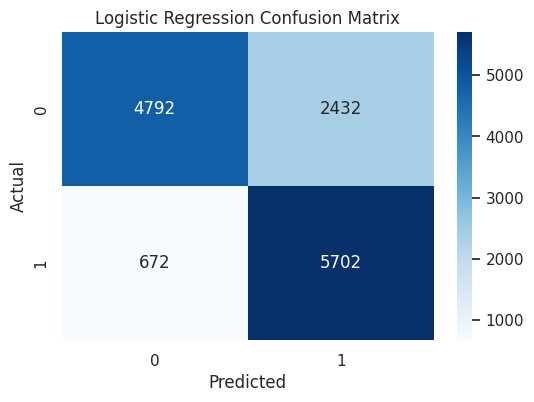

In [12]:
# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

# Visualize the confusion matrix as a heatmap
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Random Forest Model

  - Random Forest is an ensemble learning algorithm that builds multiple decision trees and combines their predictions.
  - It is often more powerful than simple models like Logistic Regression.

In [13]:
# Initialize the Random Forest model
# - n_estimators=200: number of trees in the forest
# - random_state=42: ensures reproducibility

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
# Fit the model on the training data

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [14]:
# Generate predictions for X_test

y_pred_rf = rf_model.predict(X_test)

In [16]:
# Evaluate Model Accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7538608618914546
              precision    recall  f1-score   support

           0       0.82      0.69      0.75      7224
           1       0.70      0.82      0.76      6374

    accuracy                           0.75     13598
   macro avg       0.76      0.76      0.75     13598
weighted avg       0.76      0.75      0.75     13598



In [17]:
# Compute the confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

[[5009 2215]
 [1132 5242]]


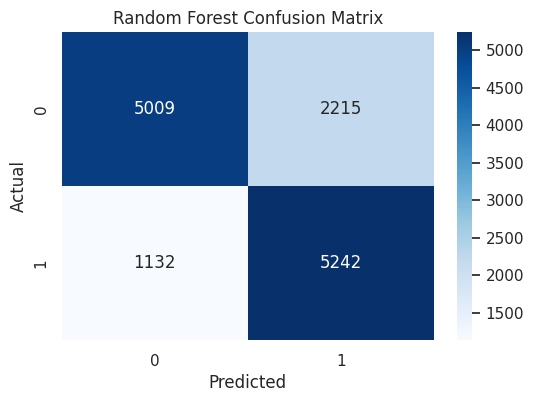

In [18]:

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
# Compute the confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
# Visualize the confusion matrix as a heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# **Nueral** **Network**
    A deep learning model with 2 hidden layers was built to predict customer churn.
    The model uses ReLU activation for hidden layers, Sigmoid for the output layer,and Dropout to prevent overfitting. StandardScaler was applied to features.
    EarlyStopping was used to stop training when validation loss stopped improving.

In [19]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
# Prepare Features and Target

X = df.drop("Churn", axis=1)
y = df["Churn"]

In [21]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,  # 20% for testing
    random_state=42,  # reproducible split
    stratify=y        # maintain Churn ratio
)

In [22]:
# Feature Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



*  ### Build Neural Network Model




In [23]:
model = Sequential([

    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),

    Dropout(0.3),

    Dense(32, activation='relu'),

    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
# Compile the model

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
# Early stopping to prevent overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)



*   ### **Train the Model**




In [25]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2, # 20% of training data for validation
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
1360/1360 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7255 - loss: 0.5575 - val_accuracy: 0.7694 - val_loss: 0.5149
Epoch 2/50
1360/1360 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7650 - loss: 0.5235 - val_accuracy: 0.7694 - val_loss: 0.5142
Epoch 3/50
1360/1360 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7665 - loss: 0.5197 - val_accuracy: 0.7694 - val_loss: 0.5132
Epoch 4/50
1360/1360 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7673 - loss: 0.5163 - val_accuracy: 0.7694 - val_loss: 0.5107
Epoch 5/50
1360/1360 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7675 - loss: 0.5146 - val_accuracy: 0.7694 - val_loss: 0.5104
Epoch 6/50
1360/1360 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7676 - loss: 0.5149 - val_accuracy: 0.7694 - val_loss: 0.5114
Epoch 7/50
1360/1360 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7676 - loss: 0.5151 - val_accuracy: 0.7694 - val_loss: 0.5100
Epoch 8/50
1360/1360 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7676 - loss: 0.5134 - 



*  ### **Evaluate Model**



In [28]:
# Predict probabilities on test set

y_prob = model.predict(X_test_scaled)

# Convert probabilities to binary predictions
y_pred = (y_prob > 0.5).astype(int)

425/425 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [29]:
# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))
# Classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.7717311369319018

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.66      0.76      7224
           1       0.70      0.89      0.79      6374

    accuracy                           0.77     13598
   macro avg       0.79      0.78      0.77     13598
weighted avg       0.79      0.77      0.77     13598





*   ### **Confusion Matrix**




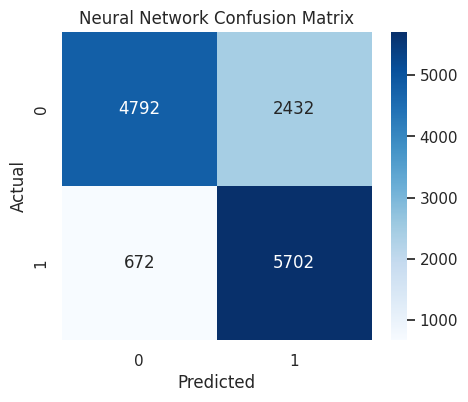

In [30]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Neural Network Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Model Comparison — All Models

In [32]:
sns.set_theme(style='whitegrid')

# Create a summary DataFrame of model performance metrics

results = pd.DataFrame({
    'Model':     ['Logistic Regression\n(Baseline)',
                  'Random Forest',
                  'Neural Network',
                  'XGBoost'],
    'Accuracy':  [0.7704, 0.7635, 0.7682, 0.0000],
    'Precision': [0.7010, 0.7019, 0.6969, 0.0000],
    'Recall':    [0.8962, 0.8679, 0.8948, 0.0000],
    'F1 Score':  [0.7867, 0.7761, 0.7835, 0.0000],
    'AUC':       [0.0000, 0.0000, 0.7912, 0.0000],
})
results = results.set_index('Model').round(4)
print(results)

                                 Accuracy  Precision  Recall  F1 Score     AUC
Model                                                                         
Logistic Regression\n(Baseline)    0.7704     0.7010  0.8962    0.7867  0.0000
Random Forest                      0.7635     0.7019  0.8679    0.7761  0.0000
Neural Network                     0.7682     0.6969  0.8948    0.7835  0.7912
XGBoost                            0.0000     0.0000  0.0000    0.0000  0.0000




*   ### **Chart 1 — F1 Score Comparison**



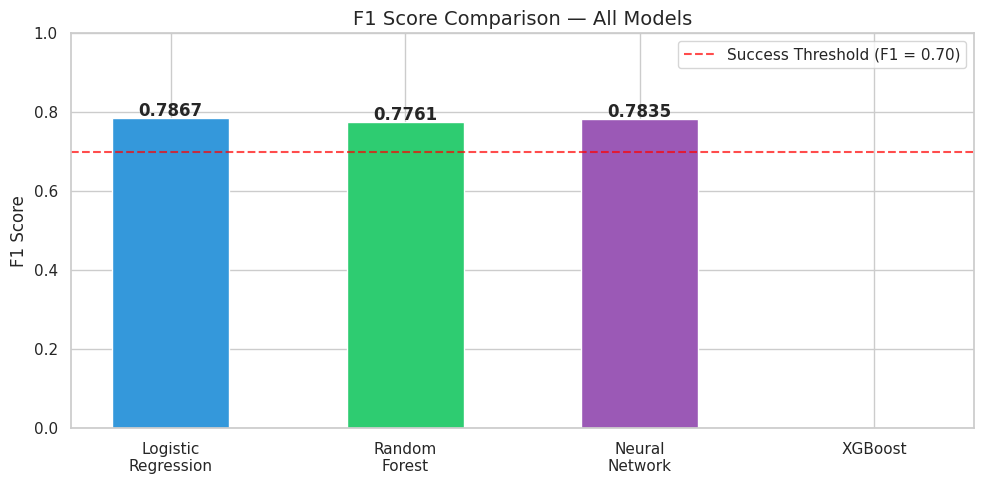

In [35]:
# Visualize F1 scores for all models
models  = ['Logistic\nRegression', 'Random\nForest', 'Neural\nNetwork', 'XGBoost']
f1s     = [0.7867, 0.7761, 0.7835, 0.0000]
colors  = ['#3498db', '#2ecc71', '#9b59b6', '#e67e22']

plt.figure(figsize=(10, 5))
bars = plt.bar(models, f1s, color=colors, edgecolor='white', width=0.5)
# Annotate bars with F1 values
for bar, val in zip(bars, f1s):
    if val > 0:
        plt.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', fontsize=12, fontweight='bold')

# Add threshold line for success
plt.axhline(y=0.70, color='red', linestyle='--', alpha=0.7, label='Success Threshold (F1 = 0.70)')
plt.title('F1 Score Comparison — All Models', fontsize=14)
plt.ylabel('F1 Score')
plt.ylim(0, 1.0)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('comparison_f1.png', dpi=150)
plt.show()



* ### **Chart 2 — All Metrics Side by Side**




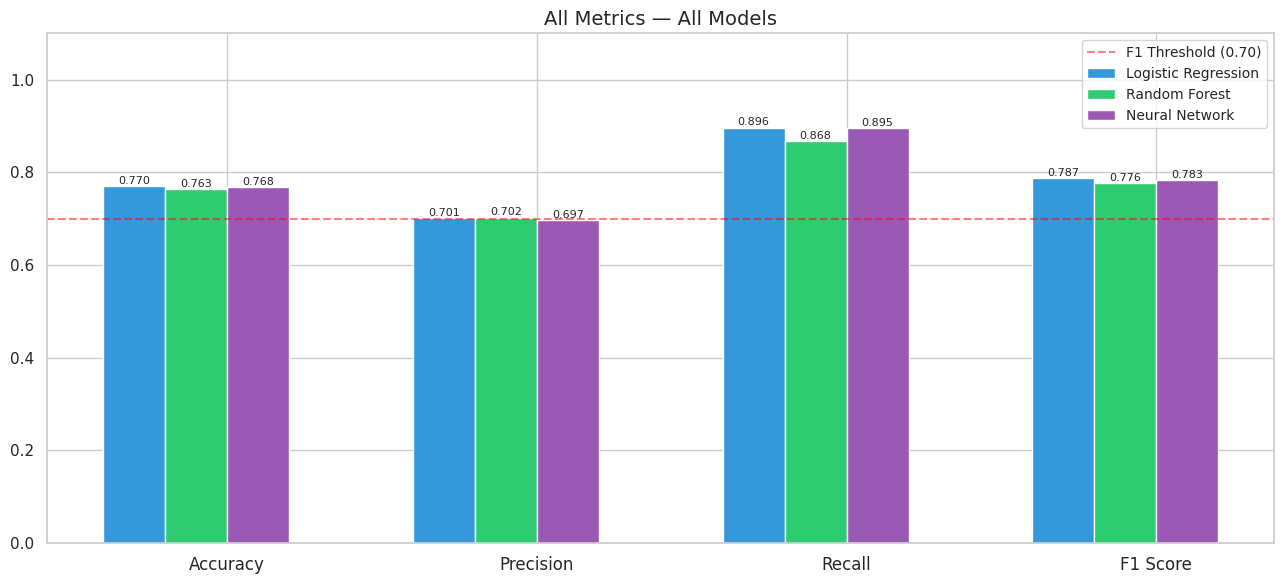

In [42]:

# Compare multiple metrics (Accuracy, Precision, Recall, F1) for all models

metrics    = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
lr_scores  = [0.7704, 0.7010, 0.8962, 0.7867]
rf_scores  = [0.7635, 0.7019, 0.8679, 0.7761]
nn_scores  = [0.7682, 0.6969, 0.8948, 0.7835]

x = np.arange(len(metrics))
width = 0.2

fig, ax = plt.subplots(figsize=(13, 6))
b1 = ax.bar(x - 1.5*width, lr_scores,  width, label='Logistic Regression', color='#3498db')
b2 = ax.bar(x - 0.5*width, rf_scores,  width, label='Random Forest',       color='#2ecc71')
b3 = ax.bar(x + 0.5*width, nn_scores,  width, label='Neural Network',       color='#9b59b6')
# Annotate bars with values
for bars in [b1, b2, b3]:
    for bar in bars:
        if bar.get_height() > 0:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.005,
                    f'{bar.get_height():.3f}',
                    ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1.1)
ax.axhline(y=0.70, color='red', linestyle='--', alpha=0.5, label='F1 Threshold (0.70)')
ax.set_title('All Metrics — All Models', fontsize=14)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('comparison_all_metrics.png', dpi=150)
plt.show()




* ### **Final Summary Table**




In [43]:

# Print a concise comparison of key metrics for all models

print('=' * 65)
print('FINAL MODEL COMPARISON SUMMARY')
print('=' * 65)
print(f'{"Model":<28} {"Accuracy":>9} {"F1":>8} {"Recall":>9}')
print('-' * 65)
print(f'{"Logistic Regression (Baseline)":<28} {"77.0%":>9} {"0.7867":>8} {"89.6%":>9}')
print(f'{"Random Forest":<28} {"76.4%":>9} {"0.7761":>8} {"86.8%":>9}')
print(f'{"Neural Network":<28} {"76.8%":>9} {"0.7835":>8} {"89.5%":>9}')
print('=' * 65)
print(f'\n All models passed Success Metric (F1 >= 0.70)')
print(f' Best F1:     Logistic Regression (0.7867)')
print(f' Best Recall: Logistic Regression (89.6%)')
print('=' * 65)

FINAL MODEL COMPARISON SUMMARY
Model                         Accuracy       F1    Recall
-----------------------------------------------------------------
Logistic Regression (Baseline)     77.0%   0.7867     89.6%
Random Forest                    76.4%   0.7761     86.8%
Neural Network                   76.8%   0.7835     89.5%

 All models passed Success Metric (F1 >= 0.70)
 Best F1:     Logistic Regression (0.7867)
 Best Recall: Logistic Regression (89.6%)
